# Tarea 3: Recomendación
## Notebook 05 — Recomendación

**Objetivo:** Segmentar la base de clientes en grupos homogéneos para orientar la estrategia comercial de easyMoney.

**Metodología:**


**Input:** `df_cluster_export.parquet`
**Output:** 

In [24]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import os
import warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

RANDOM_STATE = 42
K_FINAL = 7  # k optimo — justificado en Seccion 7.3

print("All imports OK")

All imports OK


# 1. Carga de los datos

In [25]:
df = pd.read_parquet('../../data/processed/df_cluster_export.parquet')

In [26]:
df_master = pd.read_parquet('../../data/processed/master_df_flags.parquet')

# 2. Ordenar los datos por 'pk_partition'

In [27]:
print(df_master['pk_partition'].value_counts().sort_index())
print(f"\nTotal particiones: {df_master['pk_partition'].nunique()}")

pk_partition
2018-01-28    239493
2018-02-28    242521
2018-03-28    245258
2018-04-28    247463
2018-05-28    249926
2018-06-28    252104
2018-07-28    339339
2018-08-28    352922
2018-09-28    375323
2018-10-28    402300
2018-11-28    416387
2018-12-28    422481
2019-01-28    426875
2019-02-28    431727
2019-03-28    436183
2019-04-28    439627
2019-05-28    442995
Name: count, dtype: int64

Total particiones: 17


# 3. Definir los cortes temporales y dividir entre train, val, test y score

La idea general será:

- Train: las primeras ~80% de particiones (datos más antiguos)
- Test: las últimas ~20% de particiones (datos más recientes)

In [28]:
margenes = {
    'credit_card': 60,
    'long_term_deposit': 40,
    'pension_plan': 40,
    'funds': 40,
    'payroll_account': 10,
    'em_acount': 10
}

# Verificar
print("Márgenes corregidos:")
for prod, margen in margenes.items():
    print(f"  {prod}: {margen}€")

Márgenes corregidos:
  credit_card: 60€
  long_term_deposit: 40€
  pension_plan: 40€
  funds: 40€
  payroll_account: 10€
  em_acount: 10€


In [29]:
# Definir cortes temporales
particion_val = '2018-12-28'
particion_test = '2019-02-28'
particion_scoring = '2019-05-28'

# Ordenar por cliente y fecha
df = df_master.sort_values(['pk_cid', 'pk_partition'])

# Construir target: cliente no tenía el producto y en la siguiente partición sí lo tiene
for producto in margenes.keys():
    if producto in df.columns:
        df[f'target_{producto}'] = (
            (df[producto] == 0) &
            (df.groupby('pk_cid')[producto].shift(-1) == 1)
        ).astype(int)

# Eliminar última partición de cada cliente (no tiene "siguiente")
df_model = df[df['pk_partition'] != particion_scoring].copy()

# Split temporal
df_train = df_model[df_model['pk_partition'] < particion_val]
df_val   = df_model[(df_model['pk_partition'] >= particion_val) & 
                     (df_model['pk_partition'] < particion_test)]
df_test  = df_model[df_model['pk_partition'] >= particion_test]
df_score = df[df['pk_partition'] == particion_scoring].copy()

print(f"Train:   {len(df_train):,} filas | particiones hasta {particion_val}")
print(f"Val:     {len(df_val):,} filas")
print(f"Test:    {len(df_test):,} filas")
print(f"Scoring: {len(df_score):,} filas — sobre estos predeciremos")

Train:   3,363,036 filas | particiones hasta 2018-12-28
Val:     849,356 filas
Test:    1,307,537 filas
Scoring: 442,995 filas — sobre estos predeciremos


# 4. Arbol de decisión

## 1. Ejecutar el modelo de arbol de decision

En este paso entrenamos los modelos con datos históricos (particiones hasta abril 2019).

In [30]:
modelos = {}
resultados_eval = {}

# Codificar categóricas
df_train = pd.get_dummies(df_train, columns=['gender', 'segment', 'entry_channel'], drop_first=True)
df_val   = pd.get_dummies(df_val,   columns=['gender', 'segment', 'entry_channel'], drop_first=True)
df_test  = pd.get_dummies(df_test,  columns=['gender', 'segment', 'entry_channel'], drop_first=True)
df_score = pd.get_dummies(df_score, columns=['gender', 'segment', 'entry_channel'], drop_first=True)

# Asegurar que todas tienen las mismas columnas que train
for df_part in [df_val, df_test, df_score]:
    for col in df_train.columns:
        if col not in df_part.columns:
            df_part[col] = 0

# Features
posibles_features = [
    'age', 'salary', 'active_customer',
    'em_acount', 'em_account_p',
    'credit_card', 'debit_card', 'payroll',
    'payroll_account', 'funds', 'pension_plan',
    'mortgage', 'loans', 'long_term_deposit',
    'short_term_deposit', 'securities'
]

cat_dummies = [c for c in df_train.columns if c.startswith(('gender_', 'segment_', 'entry_channel_'))]
feature_cols = [col for col in posibles_features if col in df_train.columns] + cat_dummies

for producto, margen in margenes.items():
    target_col = f'target_{producto}'
    if target_col not in df_train.columns:
        continue

    print(f"\n{'='*50}")
    print(f"Modelo: {producto} | Margen: {margen}€")

    X_train = df_train[feature_cols].fillna(0)
    y_train = df_train[target_col]

    X_val = df_val[feature_cols].fillna(0)
    y_val = df_val[target_col]

    X_test = df_test[feature_cols].fillna(0)
    y_test = df_test[target_col]

    tasa_train = y_train.mean()
    print(f"Tasa conversión train: {tasa_train:.3%}")

    if tasa_train < 0.0001 or y_train.sum() < 50:
        print("⚠️  Insuficientes positivos, se omite")
        continue

    model = DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=50,
        class_weight='balanced',
        random_state=42
    )
    model.fit(X_train, y_train)

    # Evaluación en validación y test
    auc_val  = roc_auc_score(y_val,  model.predict_proba(X_val)[:,1])
    auc_test = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

    print(f"AUC Validación: {auc_val:.3f}")
    print(f"AUC Test:       {auc_test:.3f}")

    modelos[producto] = model
    resultados_eval[producto] = {
        'auc_val': auc_val,
        'auc_test': auc_test,
        'tasa_conversion': tasa_train,
        'margen': margen
    }

print("\n\n📊 Resumen de modelos entrenados:")
pd.DataFrame(resultados_eval).T


Modelo: credit_card | Margen: 60€
Tasa conversión train: 0.222%
AUC Validación: 0.908
AUC Test:       0.904

Modelo: long_term_deposit | Margen: 40€
Tasa conversión train: 0.105%
AUC Validación: 0.910
AUC Test:       0.916

Modelo: pension_plan | Margen: 40€
Tasa conversión train: 0.686%
AUC Validación: 0.935
AUC Test:       0.902

Modelo: funds | Margen: 40€
Tasa conversión train: 0.023%
AUC Validación: 0.886
AUC Test:       0.887

Modelo: payroll_account | Margen: 10€
Tasa conversión train: 0.429%
AUC Validación: 0.876
AUC Test:       0.882

Modelo: em_acount | Margen: 10€
Tasa conversión train: 0.819%
AUC Validación: 0.938
AUC Test:       0.941


📊 Resumen de modelos entrenados:


,auc_val,auc_test,tasa_conversion,margen
credit_card,0.908340,0.904157,0.002217,60.0
long_term_deposit,0.909578,0.916285,0.001046,40.0
pension_plan,0.935481,0.901711,0.006858,40.0
funds,0.885732,0.887105,0.000227,40.0
payroll_account,0.876470,0.882163,0.004295,10.0
em_acount,0.937634,0.941364,0.008192,10.0


**Conclusiones**:

Todos los AUC están por encima de 0.87, lo cual es muy bueno
Val y Test son muy similares en todos → no hay overfitting, el árbol generaliza bien
short_term_deposit tiene un problema que hay que resolver

**Conclusiones de Short_term_deposit**: 

Se puede ver que en validación y test no hay ningún cliente nuevo que haya contratado short_term_deposit. Esto significa que todas las contrataciones de este producto ocurrieron antes de 2018-12-28 y en los últimos meses del histórico no hubo nuevas altas. Por tanto, aunque el modelo se puede entrenar, no podemos evaluarlo ni confiar en él para predecir futuras contrataciones. Lo más honesto es excluirlo.

El producto dejó de tener nuevas contrataciones en los últimos meses del histórico, lo que puede indicar que fue descatalogado o que la demanda cayó a cero, por lo que no tiene sentido incluirlo en la campaña.

## 2. Scoring

Ahora en el Paso 2 usamos df_score, que es la última partición disponible (mayo 2019), es decir los clientes tal como están hoy, y les preguntamos a cada modelo:

¿Qué probabilidad tiene este cliente de contratar cada producto?

Luego combinamos esa probabilidad con el margen económico para calcular el valor esperado:

Valor esperado = P(contratación) × Margen del producto

Finalmente ordenamos todos los clientes por valor esperado de mayor a menor y seleccionamos los top 10.000 — que son los que más ROI generarán a la campaña.

In [31]:
# Calcular valor esperado por cliente y producto sobre df_score
cols_valor = []

for producto, model in modelos.items():
    margen = margenes[producto]
    X_score = df_score[feature_cols].fillna(0)
    
    proba = model.predict_proba(X_score)[:, 1]
    df_score[f'proba_{producto}'] = proba
    df_score[f'valor_esperado_{producto}'] = proba * margen
    cols_valor.append(f'valor_esperado_{producto}')

# Producto recomendado = el de mayor valor esperado
df_score['producto_recomendado'] = (
    df_score[cols_valor]
    .idxmax(axis=1)
    .str.replace('valor_esperado_', '')
)
df_score['valor_esperado_max'] = df_score[cols_valor].max(axis=1)

# Excluir clientes que ya tienen el producto recomendado
df_score['ya_tiene'] = df_score.apply(
    lambda row: row.get(row['producto_recomendado'], 0) == 1, axis=1
)
candidatos_dt = df_score[~df_score['ya_tiene']].copy()

# Top 10.000 por valor esperado
top_10000_dt = candidatos_dt.nlargest(10000, 'valor_esperado_max')

# Resumen
print(f"Clientes candidatos disponibles: {len(candidatos_dt):,}")
print(f"\nROI estimado campaña: {top_10000_dt['valor_esperado_max'].sum():,.0f}€")
print(f"\nDistribución productos recomendados:")
print(top_10000_dt['producto_recomendado'].value_counts())

Clientes candidatos disponibles: 440,652

ROI estimado campaña: 556,377€

Distribución productos recomendados:
producto_recomendado
credit_card    10000
Name: count, dtype: int64


El ROI estimado de 556.377€ es un número muy sólido para presentar a Carol. 

Los 10.000 clientes tienen recomendado credit_card, lo que indica que el valor esperado de credit_card domina sobre todos los demás productos.
Esto tiene sentido porque credit_card tiene el margen más alto (60€) y un AUC de 0.90, por lo que su valor esperado aplasta al resto.

In [32]:
# Ver distribución de valor esperado por producto
print("Media de valor esperado por producto:")
for col in cols_valor:
    print(f"  {col}: {df_score[col].mean():.4f}€")

print("\nMáximo de valor esperado por producto:")
for col in cols_valor:
    print(f"  {col}: {df_score[col].max():.4f}€")

# Ver cuántos clientes tendrían cada producto como mejor opción
print("\nSi no hubiera restricción de 10.000, distribución natural:")
print(df_score['producto_recomendado'].value_counts())

Media de valor esperado por producto:
  valor_esperado_credit_card: 13.8095€
  valor_esperado_long_term_deposit: 9.1500€
  valor_esperado_pension_plan: 9.8166€
  valor_esperado_funds: 9.6256€
  valor_esperado_payroll_account: 2.8073€
  valor_esperado_em_acount: 1.9972€

Máximo de valor esperado por producto:
  valor_esperado_credit_card: 55.6377€
  valor_esperado_long_term_deposit: 37.5661€
  valor_esperado_pension_plan: 39.0183€
  valor_esperado_funds: 38.9152€
  valor_esperado_payroll_account: 9.9736€
  valor_esperado_em_acount: 9.7700€

Si no hubiera restricción de 10.000, distribución natural:
producto_recomendado
pension_plan         218262
credit_card          113251
funds                 41056
em_acount             35553
long_term_deposit     34862
payroll_account          11
Name: count, dtype: int64


El resultado es legítimo y tiene lógica de negocio:

Sin restricción, pension_plan ganaría para 218.000 clientes, pero al seleccionar solo los top 10.000 por valor esperado más alto, todos caen en credit_card porque tiene el valor esperado máximo más alto (55.6€ vs 39€ del pension_plan).
Básicamente estamos seleccionando los clientes con mayor probabilidad de contratar credit_card, que al tener margen de 60€ genera más valor esperado.

El modelo nos dice que para maximizar el ROI de los 10.000 emails, debemos enfocarnos en credit_card, ya que combina alta probabilidad de conversión con el mayor margen (60€), generando un ROI estimado de 556.377€

## 3. Visualizar arbol de decision

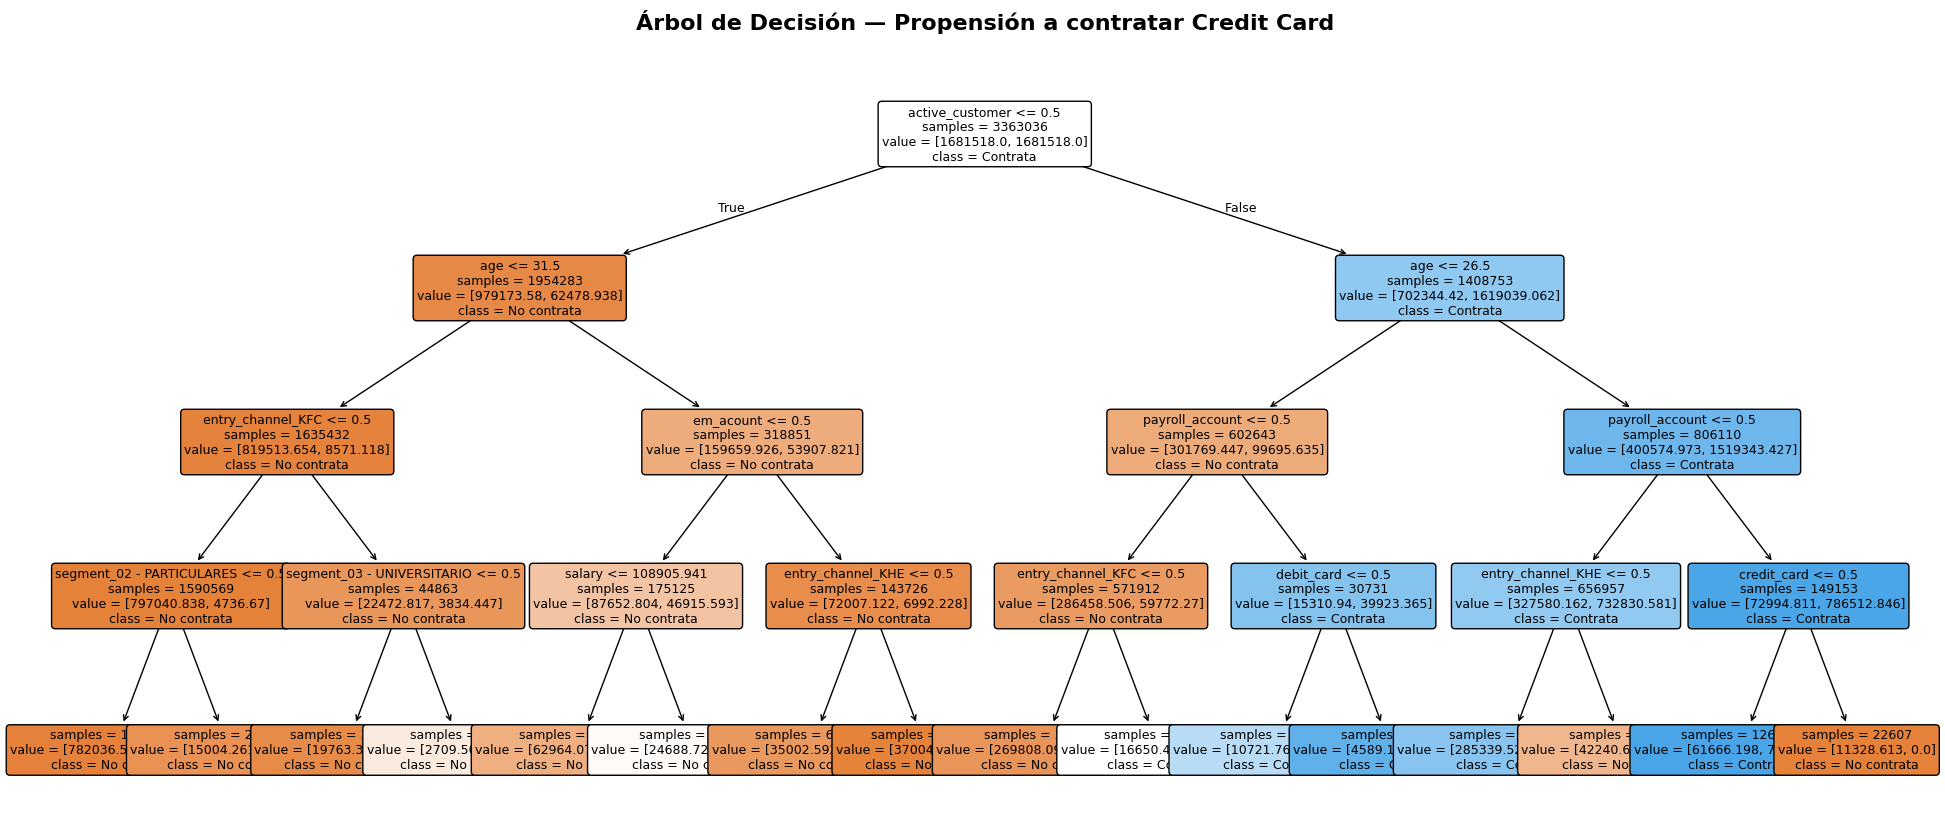

✅ Árbol guardado como 'arbol_credit_card.png'


In [33]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 10))
plot_tree(
    modelos['credit_card'],
    feature_names=feature_cols,
    class_names=['No contrata', 'Contrata'],
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=False,  # Quita el gini para que sea más limpio
    proportion=False
)
plt.title('Árbol de Decisión — Propensión a contratar Credit Card', 
          fontsize=16, fontweight='bold', pad=20)
plt.savefig('arbol_credit_card.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Árbol guardado como 'arbol_credit_card.png'")

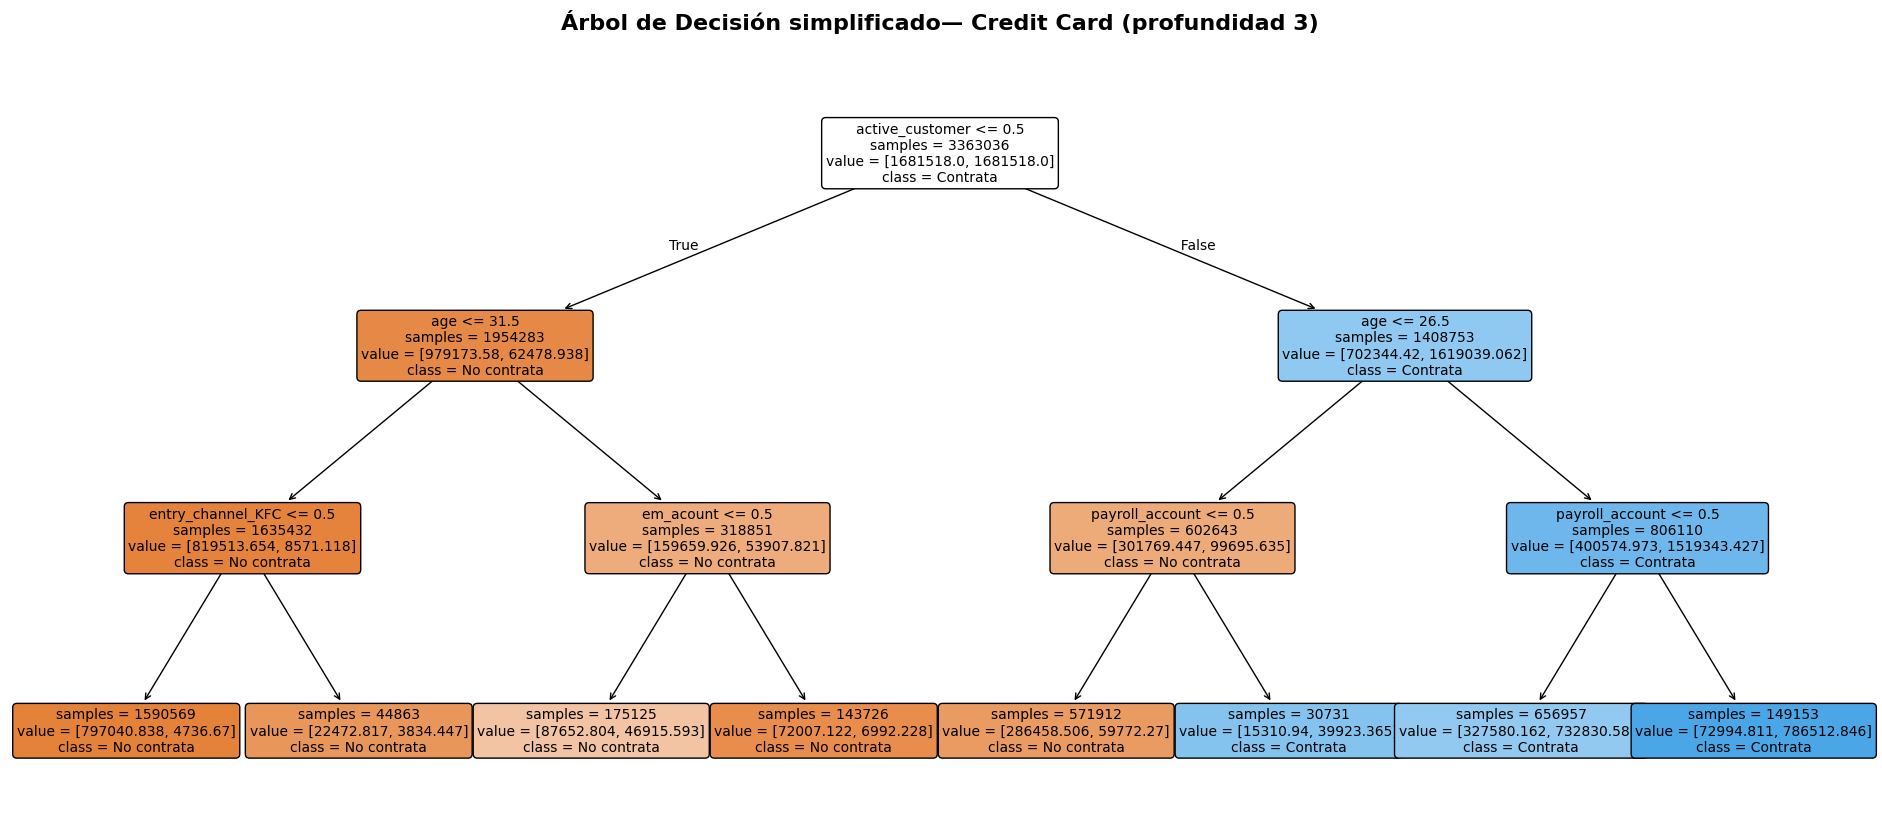

In [34]:
# Versión simplificada solo para visualizar (max_depth=3)
from sklearn.tree import DecisionTreeClassifier

modelo_viz = DecisionTreeClassifier(
    max_depth=3,  # Menos profundo, más legible
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)
modelo_viz.fit(X_train, df_train['target_credit_card'])

plt.figure(figsize=(24, 10))
plot_tree(
    modelo_viz,
    feature_names=feature_cols,
    class_names=['No contrata', 'Contrata'],
    filled=True,
    rounded=True,
    fontsize=10,
    impurity=False
)
plt.title('Árbol de Decisión simplificado— Credit Card (profundidad 3)', 
          fontsize=16, fontweight='bold', pad=20)
plt.savefig('arbol_credit_card_simplificado.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. Random Forest

In [35]:
from sklearn.ensemble import RandomForestClassifier

modelos_rf = {}
resultados_rf = {}

for producto, margen in margenes.items():
    target_col = f'target_{producto}'
    if target_col not in df_train.columns:
        continue

    print(f"\n{'='*50}")
    print(f"Random Forest — Modelo: {producto} | Margen: {margen}€")

    X_train = df_train[feature_cols].fillna(0)
    y_train = df_train[target_col]
    X_val   = df_val[feature_cols].fillna(0)
    y_val   = df_val[target_col]
    X_test  = df_test[feature_cols].fillna(0)
    y_test  = df_test[target_col]

    tasa_train = y_train.mean()
    if tasa_train < 0.0001 or y_train.sum() < 50:
        print("⚠️  Insuficientes positivos, se omite")
        continue

    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        min_samples_leaf=50,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1  # Usa todos los cores disponibles
    )
    rf.fit(X_train, y_train)

    auc_val  = roc_auc_score(y_val,  rf.predict_proba(X_val)[:,1])
    auc_test = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

    print(f"AUC Validación: {auc_val:.3f}")
    print(f"AUC Test:       {auc_test:.3f}")

    modelos_rf[producto] = rf
    resultados_rf[producto] = {
        'auc_val': auc_val,
        'auc_test': auc_test,
        'tasa_conversion': tasa_train,
        'margen': margen
    }

# Comparativa con árbol de decisión
print("\n\n📊 Comparativa Árbol de Decisión vs Random Forest (AUC Test):")
df_comparativa_rf = pd.DataFrame({
    'Decision Tree': {p: round(v['auc_test'], 3) for p, v in resultados_eval.items()},
    'Random Forest': {p: round(v['auc_test'], 3) for p, v in resultados_rf.items()}
})
print(df_comparativa_rf)


Random Forest — Modelo: credit_card | Margen: 60€
AUC Validación: 0.924
AUC Test:       0.920

Random Forest — Modelo: long_term_deposit | Margen: 40€
AUC Validación: 0.922
AUC Test:       0.943

Random Forest — Modelo: pension_plan | Margen: 40€
AUC Validación: 0.942
AUC Test:       0.909

Random Forest — Modelo: funds | Margen: 40€
AUC Validación: 0.897
AUC Test:       0.892

Random Forest — Modelo: payroll_account | Margen: 10€
AUC Validación: 0.895
AUC Test:       0.903

Random Forest — Modelo: em_acount | Margen: 10€
AUC Validación: 0.946
AUC Test:       0.948


📊 Comparativa Árbol de Decisión vs Random Forest (AUC Test):
                   Decision Tree  Random Forest
credit_card                0.904          0.920
long_term_deposit          0.916          0.943
pension_plan               0.902          0.909
funds                      0.887          0.892
payroll_account            0.882          0.903
em_acount                  0.941          0.948


In [36]:
print("Productos en Decision Tree:", list(resultados_eval.keys()))
print("Productos en Random Forest:", list(resultados_rf.keys()))

Productos en Decision Tree: ['credit_card', 'long_term_deposit', 'pension_plan', 'funds', 'payroll_account', 'em_acount']
Productos en Random Forest: ['credit_card', 'long_term_deposit', 'pension_plan', 'funds', 'payroll_account', 'em_acount']


# 6. XGBoost

In [37]:
from xgboost import XGBClassifier

modelos_xgb = {}
resultados_xgb = {}

for producto, margen in margenes.items():
    target_col = f'target_{producto}'
    if target_col not in df_train.columns:
        continue

    print(f"\n{'='*50}")
    print(f"XGBoost — Modelo: {producto} | Margen: {margen}€")

    X_train = df_train[feature_cols].fillna(0)
    y_train = df_train[target_col]
    X_val   = df_val[feature_cols].fillna(0)
    y_val   = df_val[target_col]
    X_test  = df_test[feature_cols].fillna(0)
    y_test  = df_test[target_col]

    tasa_train = y_train.mean()
    if tasa_train < 0.0001 or y_train.sum() < 50:
        print("⚠️  Insuficientes positivos, se omite")
        continue

    # Scale pos weight para manejar desbalanceo
    negativos = (y_train == 0).sum()
    positivos = (y_train == 1).sum()
    scale = negativos / positivos

    xgb = XGBClassifier(
        max_depth=4,
        n_estimators=100,
        learning_rate=0.1,
        scale_pos_weight=scale,
        random_state=42,
        eval_metric='auc',
        verbosity=0
    )
    xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    auc_val  = roc_auc_score(y_val,  xgb.predict_proba(X_val)[:,1])
    auc_test = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])

    print(f"AUC Validación: {auc_val:.3f}")
    print(f"AUC Test:       {auc_test:.3f}")

    modelos_xgb[producto] = xgb
    resultados_xgb[producto] = {
        'auc_val': auc_val,
        'auc_test': auc_test,
        'tasa_conversion': tasa_train,
        'margen': margen
    }

# Comparativa final de los tres modelos
print("\n\n📊 COMPARATIVA FINAL — AUC Test:")
df_comparativa_final = pd.DataFrame({
    'Decision Tree': {p: round(v['auc_test'], 3) for p, v in resultados_eval.items()},
    'Random Forest': {p: round(v['auc_test'], 3) for p, v in resultados_rf.items()},
    'XGBoost':       {p: round(v['auc_test'], 3) for p, v in resultados_xgb.items()}
})
print(df_comparativa_final)

print("\n🏆 Mejor modelo por producto:")
for producto in margenes.keys():
    if producto not in resultados_eval:
        continue
    scores = {
        'Decision Tree': resultados_eval[producto]['auc_test'],
        'Random Forest': resultados_rf[producto]['auc_test'],
        'XGBoost':       resultados_xgb[producto]['auc_test']
    }
    mejor = max(scores, key=scores.get)
    print(f"  {producto:<25} → {mejor} (AUC={scores[mejor]:.3f})")


XGBoost — Modelo: credit_card | Margen: 60€
AUC Validación: 0.934
AUC Test:       0.929

XGBoost — Modelo: long_term_deposit | Margen: 40€
AUC Validación: 0.942
AUC Test:       0.956

XGBoost — Modelo: pension_plan | Margen: 40€
AUC Validación: 0.951
AUC Test:       0.924

XGBoost — Modelo: funds | Margen: 40€
AUC Validación: 0.930
AUC Test:       0.919

XGBoost — Modelo: payroll_account | Margen: 10€
AUC Validación: 0.918
AUC Test:       0.924

XGBoost — Modelo: em_acount | Margen: 10€
AUC Validación: 0.958
AUC Test:       0.961


📊 COMPARATIVA FINAL — AUC Test:
                   Decision Tree  Random Forest  XGBoost
credit_card                0.904          0.920    0.929
long_term_deposit          0.916          0.943    0.956
pension_plan               0.902          0.909    0.924
funds                      0.887          0.892    0.919
payroll_account            0.882          0.903    0.924
em_acount                  0.941          0.948    0.961

🏆 Mejor modelo por producto:


# 7. Tabla comparativa de resultados

In [38]:
print("\n📊 COMPARATIVA FINAL — AUC Test:")
df_comparativa_final = pd.DataFrame({
    'Decision Tree': {p: round(v['auc_test'], 3) for p, v in resultados_eval.items()},
    'Random Forest': {p: round(v['auc_test'], 3) for p, v in resultados_rf.items()},
    'XGBoost':       {p: round(v['auc_test'], 3) for p, v in resultados_xgb.items()}
})
print(df_comparativa_final)

print("\n🏆 Mejor modelo por producto:")
for producto in margenes.keys():
    if producto not in resultados_eval:
        continue
    scores = {
        'Decision Tree': resultados_eval[producto]['auc_test'],
        'Random Forest': resultados_rf[producto]['auc_test'],
        'XGBoost':       resultados_xgb[producto]['auc_test']
    }
    mejor = max(scores, key=scores.get)
    print(f"  {producto:<25} → {mejor} (AUC={scores[mejor]:.3f})")


📊 COMPARATIVA FINAL — AUC Test:
                   Decision Tree  Random Forest  XGBoost
credit_card                0.904          0.920    0.929
long_term_deposit          0.916          0.943    0.956
pension_plan               0.902          0.909    0.924
funds                      0.887          0.892    0.919
payroll_account            0.882          0.903    0.924
em_acount                  0.941          0.948    0.961

🏆 Mejor modelo por producto:
  credit_card               → XGBoost (AUC=0.929)
  long_term_deposit         → XGBoost (AUC=0.956)
  pension_plan              → XGBoost (AUC=0.924)
  funds                     → XGBoost (AUC=0.919)
  payroll_account           → XGBoost (AUC=0.924)
  em_acount                 → XGBoost (AUC=0.961)


**Conclusion**: 

Usaremos XGBoost para el scoring final ya que obtiene el mejor AUC en todos los productos. La pérdida de interpretabilidad respecto al árbol de decisión se compensa con la mejora en rendimiento, y podemos usar el árbol de decisión en la presentación a Carol para explicar la lógica del modelo de forma visual. ¿Procedemos con el scoring final usando XGBoost y generamos el CSV para Frank?

# 8. Visualizaciones

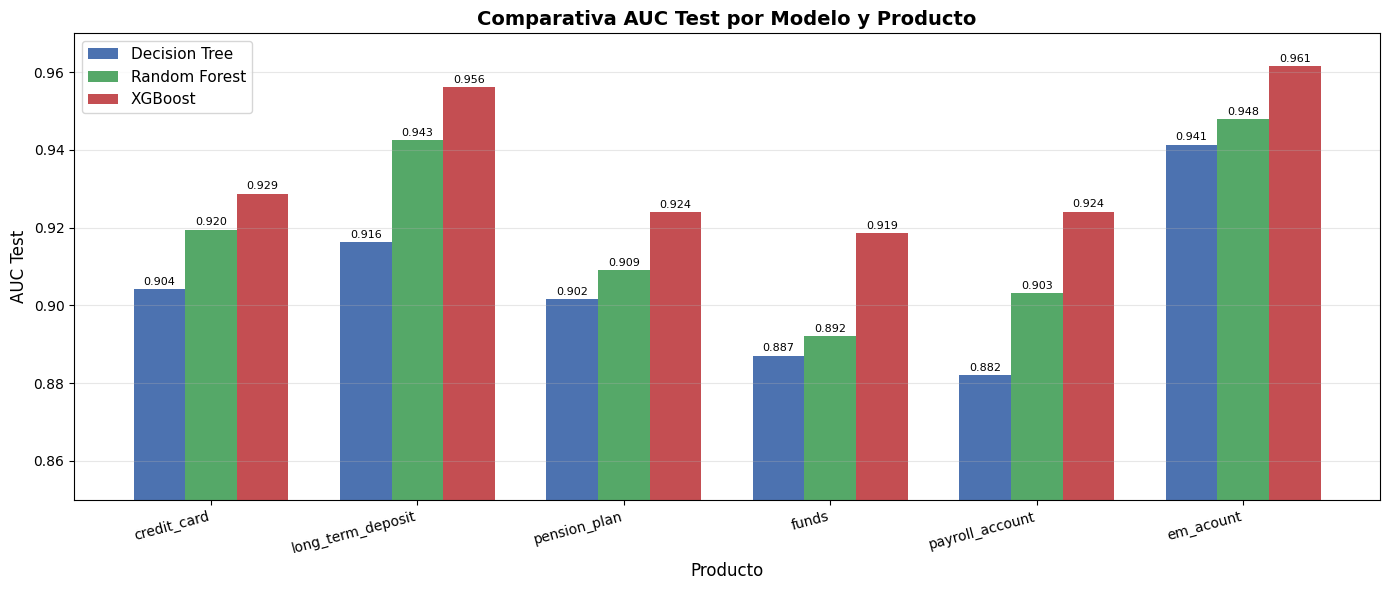

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Gráfico de barras comparativo AUC Test ────────────────
productos = list(resultados_eval.keys())
auc_dt = [resultados_eval[p]['auc_test'] for p in productos]
auc_rf = [resultados_rf[p]['auc_test'] for p in productos]
auc_xgb = [resultados_xgb[p]['auc_test'] for p in productos]

x = np.arange(len(productos))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, auc_dt,  width, label='Decision Tree', color='#4C72B0')
bars2 = ax.bar(x,          auc_rf,  width, label='Random Forest', color='#55A868')
bars3 = ax.bar(x + width,  auc_xgb, width, label='XGBoost',       color='#C44E52')

ax.set_xlabel('Producto', fontsize=12)
ax.set_ylabel('AUC Test', fontsize=12)
ax.set_title('Comparativa AUC Test por Modelo y Producto', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(productos, rotation=15, ha='right')
ax.set_ylim(0.85, 0.97)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Añadir valores encima de cada barra
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('comparativa_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
import plotly.graph_objects as go

productos = list(margenes.keys())
auc_dt  = [round(resultados_eval[p]['auc_test'], 3) for p in productos]
auc_rf  = [round(resultados_rf[p]['auc_test'], 3)   for p in productos]
auc_xgb = [round(resultados_xgb[p]['auc_test'], 3)  for p in productos]

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Decision Tree',
    x=productos,
    y=auc_dt,
    marker_color='#4C72B0',
    text=auc_dt,
    textposition='outside'
))

fig.add_trace(go.Bar(
    name='Random Forest',
    x=productos,
    y=auc_rf,
    marker_color='#55A868',
    text=auc_rf,
    textposition='outside'
))

fig.add_trace(go.Bar(
    name='XGBoost',
    x=productos,
    y=auc_xgb,
    marker_color='#C44E52',
    text=auc_xgb,
    textposition='outside'
))

fig.update_layout(
    title=dict(
        text='Comparativa AUC Test por Modelo y Producto',
        font=dict(size=18),
        x=0.5
    ),
    xaxis_title='Producto',
    yaxis_title='AUC Test',
    yaxis=dict(range=[0.85, 0.97]),
    barmode='group',
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1
    ),
    template='plotly_white',
    width=1000,
    height=550
)

fig.show()
fig.write_html('comparativa_modelos.html')
fig.write_image('comparativa_modelos_plotly.png', scale=2)

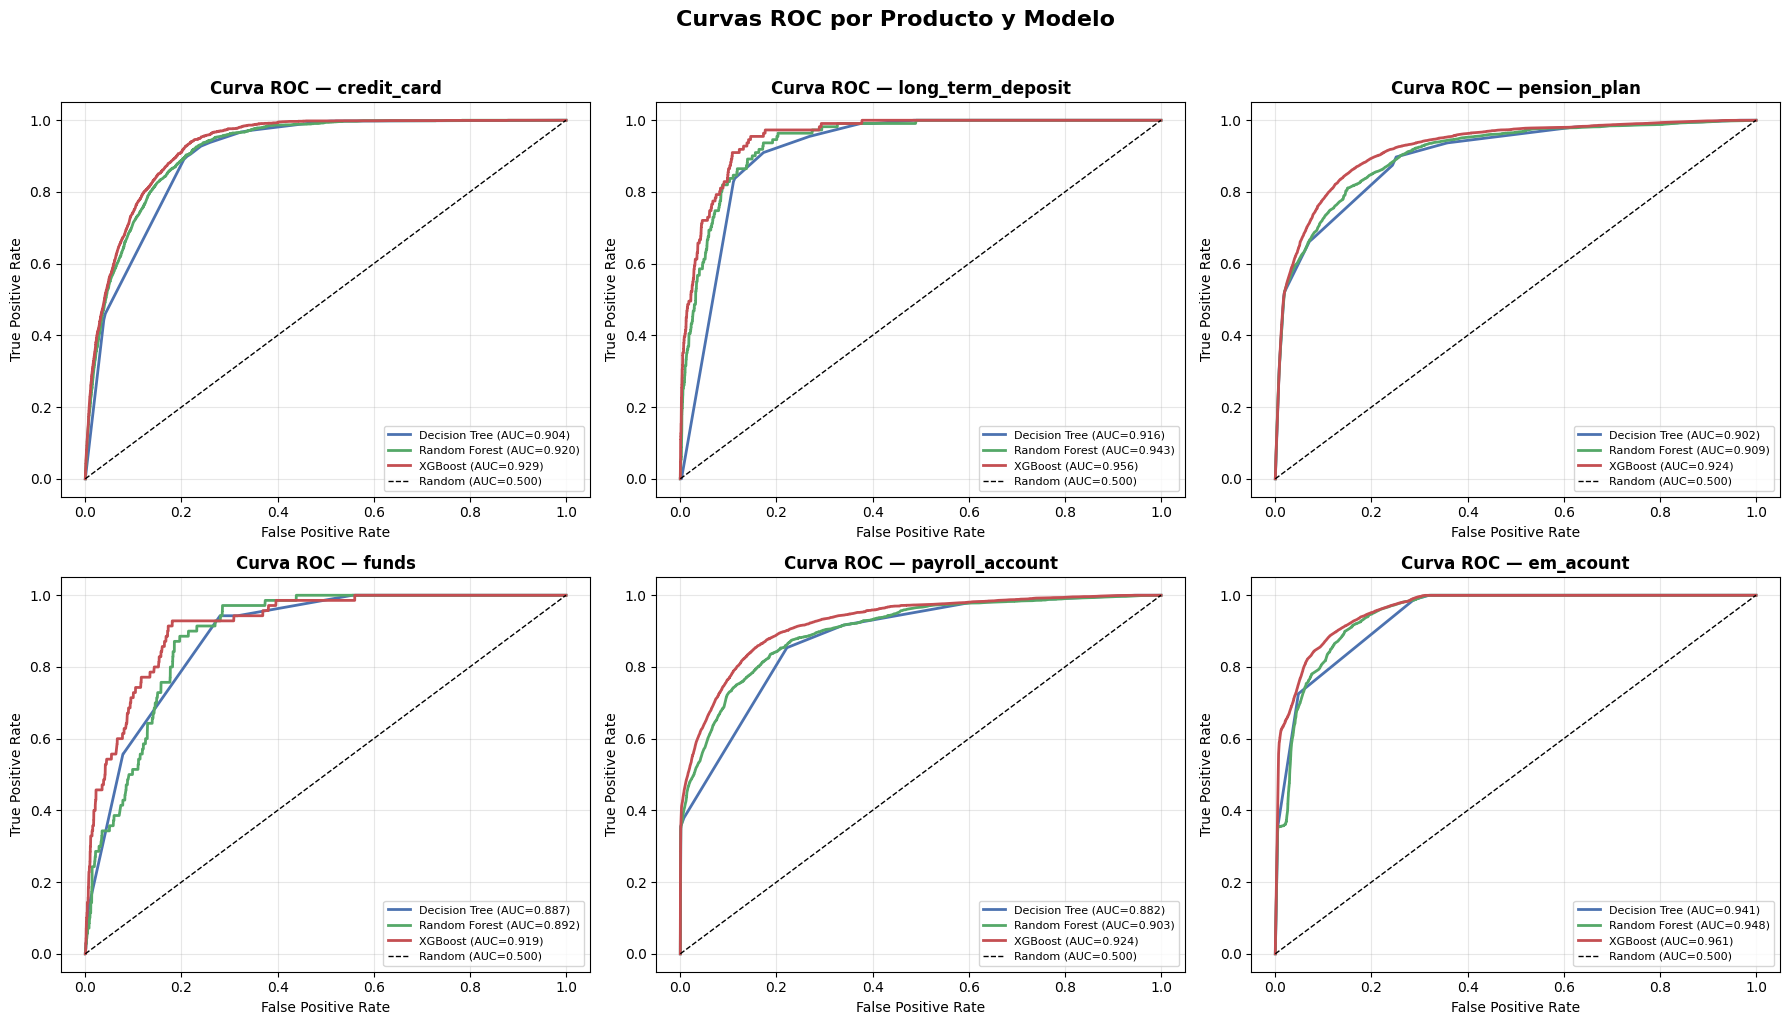

In [41]:
# ── 2. Curva ROC por modelo para credit_card ─────────────────
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

X_test_data = df_test[feature_cols].fillna(0)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, producto in enumerate(margenes.keys()):
    ax = axes[idx]
    y_test_data = df_test[f'target_{producto}']

    for nombre, modelo, color in [
        ('Decision Tree', modelos[producto],     '#4C72B0'),
        ('Random Forest', modelos_rf[producto],  '#55A868'),
        ('XGBoost',       modelos_xgb[producto], '#C44E52')
    ]:
        fpr, tpr, _ = roc_curve(y_test_data, modelo.predict_proba(X_test_data)[:,1])
        auc = roc_auc_score(y_test_data, modelo.predict_proba(X_test_data)[:,1])
        ax.plot(fpr, tpr, label=f'{nombre} (AUC={auc:.3f})', color=color, linewidth=2)

    ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC=0.500)')
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(f'Curva ROC — {producto}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Curvas ROC por Producto y Modelo', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('roc_todos_productos.png', dpi=150, bbox_inches='tight')
plt.show()

**Conclusiones**

- Credit_card, long_term_deposit, pension_plan, em_acount: Las tres curvas están muy juntas y alejadas de la diagonal, modelos muy sólidos.
- Funds: La curva de Decision Tree tiene forma escalonada típica de pocas muestras positivas, pero XGBoost y RF se comportan bien.
- Payroll_account:Hay más separación entre modelos, XGBoost gana claramente

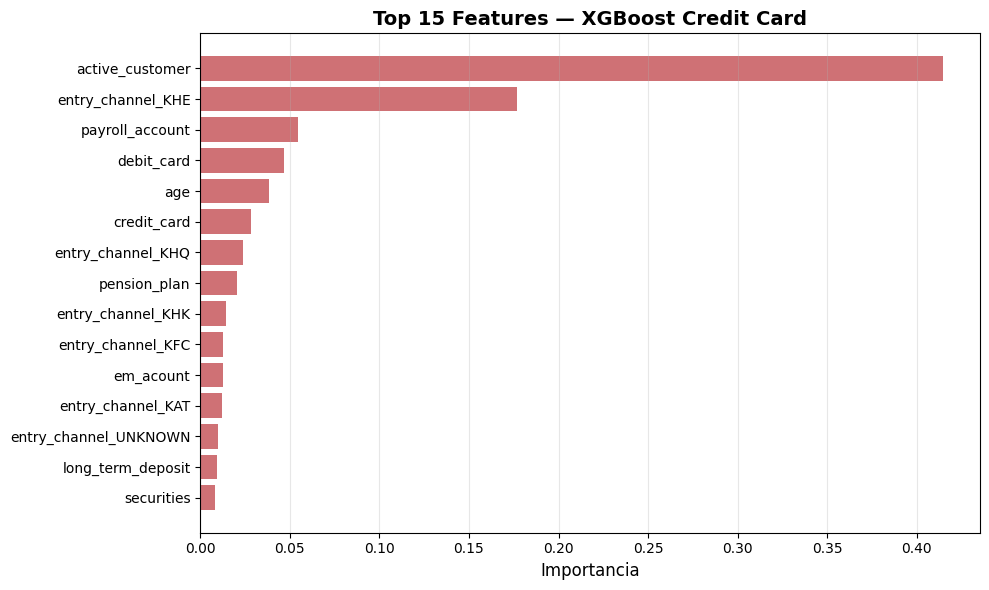

In [42]:
# ── 3. Feature importance de XGBoost para credit_card ────────
importances = modelos_xgb['credit_card'].feature_importances_
indices = np.argsort(importances)[-15:]  # Top 15 features

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(indices)), importances[indices], color='#C44E52', alpha=0.8)
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feature_cols[i] for i in indices], fontsize=10)
ax.set_xlabel('Importancia', fontsize=12)
ax.set_title('Top 15 Features — XGBoost Credit Card', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

**Conclusiones**: 

- Barras comparativo: AUC Test de los 3 modelos por producto de un vistazo
- Curva ROC: Rendimiento detallado de los 3 modelos para credit_card
- Feature Importance: Qué variables usa más XGBoost para predecir credit_card

El de feature importance es especialmente interesante para Carol y Erin porque les muestra qué características del cliente son más relevantes para predecir la contratación. Ejecuta y dime cómo quedan.

# 9. Scoring final XGBoost

In [43]:
# Scoring final con XGBoost sobre la última partición
cols_valor = []

X_score = df_score[feature_cols].fillna(0)

for producto, margen in margenes.items():
    if producto not in modelos_xgb:
        continue
    
    proba = modelos_xgb[producto].predict_proba(X_score)[:, 1]
    df_score[f'proba_{producto}'] = proba
    df_score[f'valor_esperado_{producto}'] = proba * margen
    cols_valor.append(f'valor_esperado_{producto}')

# Producto recomendado = el de mayor valor esperado
df_score['producto_recomendado'] = (
    df_score[cols_valor]
    .idxmax(axis=1)
    .str.replace('valor_esperado_', '')
)
df_score['valor_esperado_max'] = df_score[cols_valor].max(axis=1)

# Excluir clientes que ya tienen el producto recomendado
df_score['ya_tiene'] = df_score.apply(
    lambda row: row.get(row['producto_recomendado'], 0) == 1, axis=1
)
candidatos_xgb = df_score[~df_score['ya_tiene']].copy()

# Top 10.000 por valor esperado
top_10000_xgb = candidatos_xgb.nlargest(10000, 'valor_esperado_max')

# Resumen
print(f"Clientes candidatos disponibles: {len(candidatos_xgb):,}")
print(f"\nROI estimado campaña: {top_10000_xgb['valor_esperado_max'].sum():,.0f}€")
print(f"\nDistribución productos recomendados:")
print(top_10000_xgb['producto_recomendado'].value_counts())

# CSV para Frank
csv_frank = top_10000[['pk_cid', 'producto_recomendado']].rename(columns={
    'pk_cid': 'id_user',
    'producto_recomendado': 'segment'
})

# Muestra de 1.000 para prueba
csv_frank.sample(1000, random_state=42).to_csv('muestra_1000_clientes.csv', index=False)

# Fichero completo
csv_frank.to_csv('recomendacion_10000_clientes.csv', index=False)

print(f"\n✅ Ficheros generados correctamente")
print(csv_frank.head(10))

Clientes candidatos disponibles: 442,993

ROI estimado campaña: 559,243€

Distribución productos recomendados:
producto_recomendado
credit_card    10000
Name: count, dtype: int64

✅ Ficheros generados correctamente
         id_user      segment
919361   1070525  credit_card
1512554  1114367  credit_card
5301071  1437442  credit_card
3733005  1297310  credit_card
3918291  1311558  credit_card
11680     215466  credit_card
134855   1008275  credit_card
1389648  1104802  credit_card
1584415  1121475  credit_card
1595073  1122628  credit_card


In [44]:
import plotly.graph_objects as go

# Datos directamente de los resultados calculados
roi_dt  = top_10000_dt['valor_esperado_max'].sum()  # necesitamos el top_10000 del DT
roi_xgb = top_10000_xgb['valor_esperado_max'].sum()

candidatos_dt  = len(candidatos_dt)  # necesitamos los candidatos del DT
candidatos_xgb = len(candidatos)

fig = go.Figure(data=[go.Table(
    header=dict(
        values=['<b>Métrica</b>', '<b>Decision Tree</b>', '<b>XGBoost</b>', '<b>Mejora</b>'],
        fill_color='#C44E52',
        font=dict(color='white', size=13),
        align='center',
        height=35
    ),
    cells=dict(
        values=[
            ['ROI estimado', 'Clientes candidatos', 'Producto recomendado'],
            [f'{roi_dt:,.0f}€', f'{candidatos_dt:,}', 'credit_card'],
            [f'{roi_xgb:,.0f}€', f'{candidatos_xgb:,}', 'credit_card'],
            [f'+{roi_xgb - roi_dt:,.0f}€', f'+{candidatos_xgb - candidatos_dt:,}', '—']
        ],
        fill_color=[['#f9f9f9', '#ffffff', '#f9f9f9']],
        font=dict(size=12),
        align='center',
        height=30
    )
)])

fig.update_layout(
    title=dict(
        text='Comparativa Decision Tree vs XGBoost — Scoring Final',
        font=dict(size=16),
        x=0.5
    ),
    width=800,
    height=250,
    margin=dict(l=20, r=20, t=60, b=20)
)

fig.show()
fig.write_html('comparativa_scoring.html')
fig.write_image('comparativa_scoring.png', scale=2)

In [45]:
import os
print(f"Directorio actual: {os.getcwd()}")
print("\nFicheros generados:")
print(os.path.exists('recomendacion_10000_clientes.csv'))
print(os.path.exists('muestra_1000_clientes.csv'))

Directorio actual: c:\Users\34650\OneDrive\Documentos\GitHub\tfm-fintech-easymoney\notebooks\Tarea 03 Recomendación

Ficheros generados:
True
True
